In [2]:
import pandas as pd
import tables

raw_df = pd.read_hdf('VNAT_Dataframe_release_1.h5')
raw_df.head()

,connection,timestamps,sizes,directions,file_names
0,"(10.123.1.2, 1195, 10.123.1.1, 1195, 17)","[1563289706.330096, 1563289706.330207, 1563289...","[120, 88, 120, 88, 120, 88, 120, 120, 152, 120...","[1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, ...",vpn_youtube_capture2.pcap
0,"(10.113.1.2, 22924, 10.115.1.2, 53, 17)","[1561391908.523659, 1561391908.524042]","[63, 79]","[1, 0]",nonvpn_sftp_newcapture1.pcap
1,"(10.113.1.2, 53065, 10.115.1.2, 53, 17)","[1561391908.523706, 1561391908.524059]","[63, 63]","[1, 0]",nonvpn_sftp_newcapture1.pcap
2,"(10.113.1.150, 39816, 10.115.1.123, 22, 6)","[1561391908.524836, 1561391908.525027, 1561391...","[60, 60, 52, 73, 52, 73, 52, 1378, 222, 52, 13...","[1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, ...",nonvpn_sftp_newcapture1.pcap
3,"(10.115.1.2, 6589, 10.113.1.2, 53, 17)","[1561391908.594887, 1561391908.595301]","[51, 102]","[1, 0]",nonvpn_sftp_newcapture1.pcap


In [3]:
feature_df = pd.read_hdf('VNAT_Feature_Dataframe_release_1.h5')
feature_df.head()

,out_iat_min,out_iat_max,out_iat_mean,out_iat_std_dev,in_iat_min,in_iat_max,in_iat_mean,in_iat_std_dev,flow_iat_min,flow_iat_max,...,out_log_std_dev_detail_coeffs_4,out_log_std_dev_detail_coeffs_5,out_log_std_dev_detail_coeffs_6,out_log_std_dev_detail_coeffs_7,out_log_std_dev_detail_coeffs_8,out_log_std_dev_detail_coeffs_9,out_log_std_dev_detail_coeffs_10,out_log_std_dev_detail_coeffs_11,out_log_std_dev_detail_coeffs_12,labels
0,0.000024,15.646865,0.891706,3.579154,0.000054,15.607829,0.842655,3.480432,0.000024,15.607655,...,0.958770,1.279343,1.569488,1.790519,2.070103,2.096996,2.428894,2.759263,2.904293,C2
1,0.001351,10.258183,3.232542,2.992364,0.018239,10.202419,1.941929,2.765867,0.000105,10.202419,...,0.251599,0.637307,1.005774,1.309230,1.554615,1.820888,2.220975,2.554422,2.914594,CHAT
2,0.028768,4.019976,1.227752,1.278413,0.026368,3.980284,1.123653,1.264388,0.001719,3.978565,...,0.014055,0.420507,0.762716,1.109513,1.471456,1.754881,2.001594,2.351996,2.736217,CHAT
3,0.030268,3.264299,1.456833,1.292042,0.029519,3.226012,1.458189,1.291581,0.001323,3.224246,...,0.023604,0.542705,0.945885,1.278526,1.571150,1.862637,2.113894,2.454169,2.844140,CHAT
4,0.025157,3.391598,1.068763,1.193896,0.028530,3.332177,1.131416,1.185435,0.001574,3.329872,...,0.155742,0.459030,0.914504,1.178986,1.553150,1.858731,2.111992,2.449052,2.836318,CHAT


In [4]:
feature_df.shape

(15093, 130)

In [5]:
raw_df.shape

(33711, 5)

In [6]:
#Parse file names to extract vpn vs non vpn
raw_df['is_vpn'] = raw_df['file_names'].str.startswith('vpn_')

#specifiy application name from file_names
raw_df['app_name'] = raw_df['file_names'].str.split('_').str[1]

#map each app to one of the 5 traffic categories
# Extract app name from filename
raw_df['app'] = raw_df['file_names'].str.extract(r'(?:non)?vpn_(.+?)_(?:new)?capture')

# Map app to category
app_to_category = {
    'netflix':      'STREAMING',
    'youtube':      'STREAMING',
    'vimeo':        'STREAMING',
    'voip':         'VOIP',
    'skype-chat':   'CHAT',
    'sftp':         'FILE_TRANSFER',
    'scp':          'FILE_TRANSFER',
    'rsync':        'FILE_TRANSFER',
    'ssh':          'FILE_TRANSFER',
    'rdp':          'C2',
}

raw_df['category'] = raw_df['app'].map(app_to_category)



raw_df.head()

,connection,timestamps,sizes,directions,file_names,is_vpn,app_name,app,category
0,"(10.123.1.2, 1195, 10.123.1.1, 1195, 17)","[1563289706.330096, 1563289706.330207, 1563289...","[120, 88, 120, 88, 120, 88, 120, 120, 152, 120...","[1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, ...",vpn_youtube_capture2.pcap,True,youtube,youtube,STREAMING
0,"(10.113.1.2, 22924, 10.115.1.2, 53, 17)","[1561391908.523659, 1561391908.524042]","[63, 79]","[1, 0]",nonvpn_sftp_newcapture1.pcap,False,sftp,sftp,FILE_TRANSFER
1,"(10.113.1.2, 53065, 10.115.1.2, 53, 17)","[1561391908.523706, 1561391908.524059]","[63, 63]","[1, 0]",nonvpn_sftp_newcapture1.pcap,False,sftp,sftp,FILE_TRANSFER
2,"(10.113.1.150, 39816, 10.115.1.123, 22, 6)","[1561391908.524836, 1561391908.525027, 1561391...","[60, 60, 52, 73, 52, 73, 52, 1378, 222, 52, 13...","[1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, ...",nonvpn_sftp_newcapture1.pcap,False,sftp,sftp,FILE_TRANSFER
3,"(10.115.1.2, 6589, 10.113.1.2, 53, 17)","[1561391908.594887, 1561391908.595301]","[51, 102]","[1, 0]",nonvpn_sftp_newcapture1.pcap,False,sftp,sftp,FILE_TRANSFER


Empty flows:         0
Single-packet flows: 27
Zero-duration flows: 27
Missing categories:  10555

Packet count outliers (>99th pct): 336
Duration outliers (>99th pct):     338


C:\Users\apier\AppData\Local\Temp\ipykernel_13928\4167234449.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(cat_data, labels=categories, showfliers=False)
C:\Users\apier\AppData\Local\Temp\ipykernel_13928\4167234449.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2,0].boxplot(dur_data, labels=categories, showfliers=False)


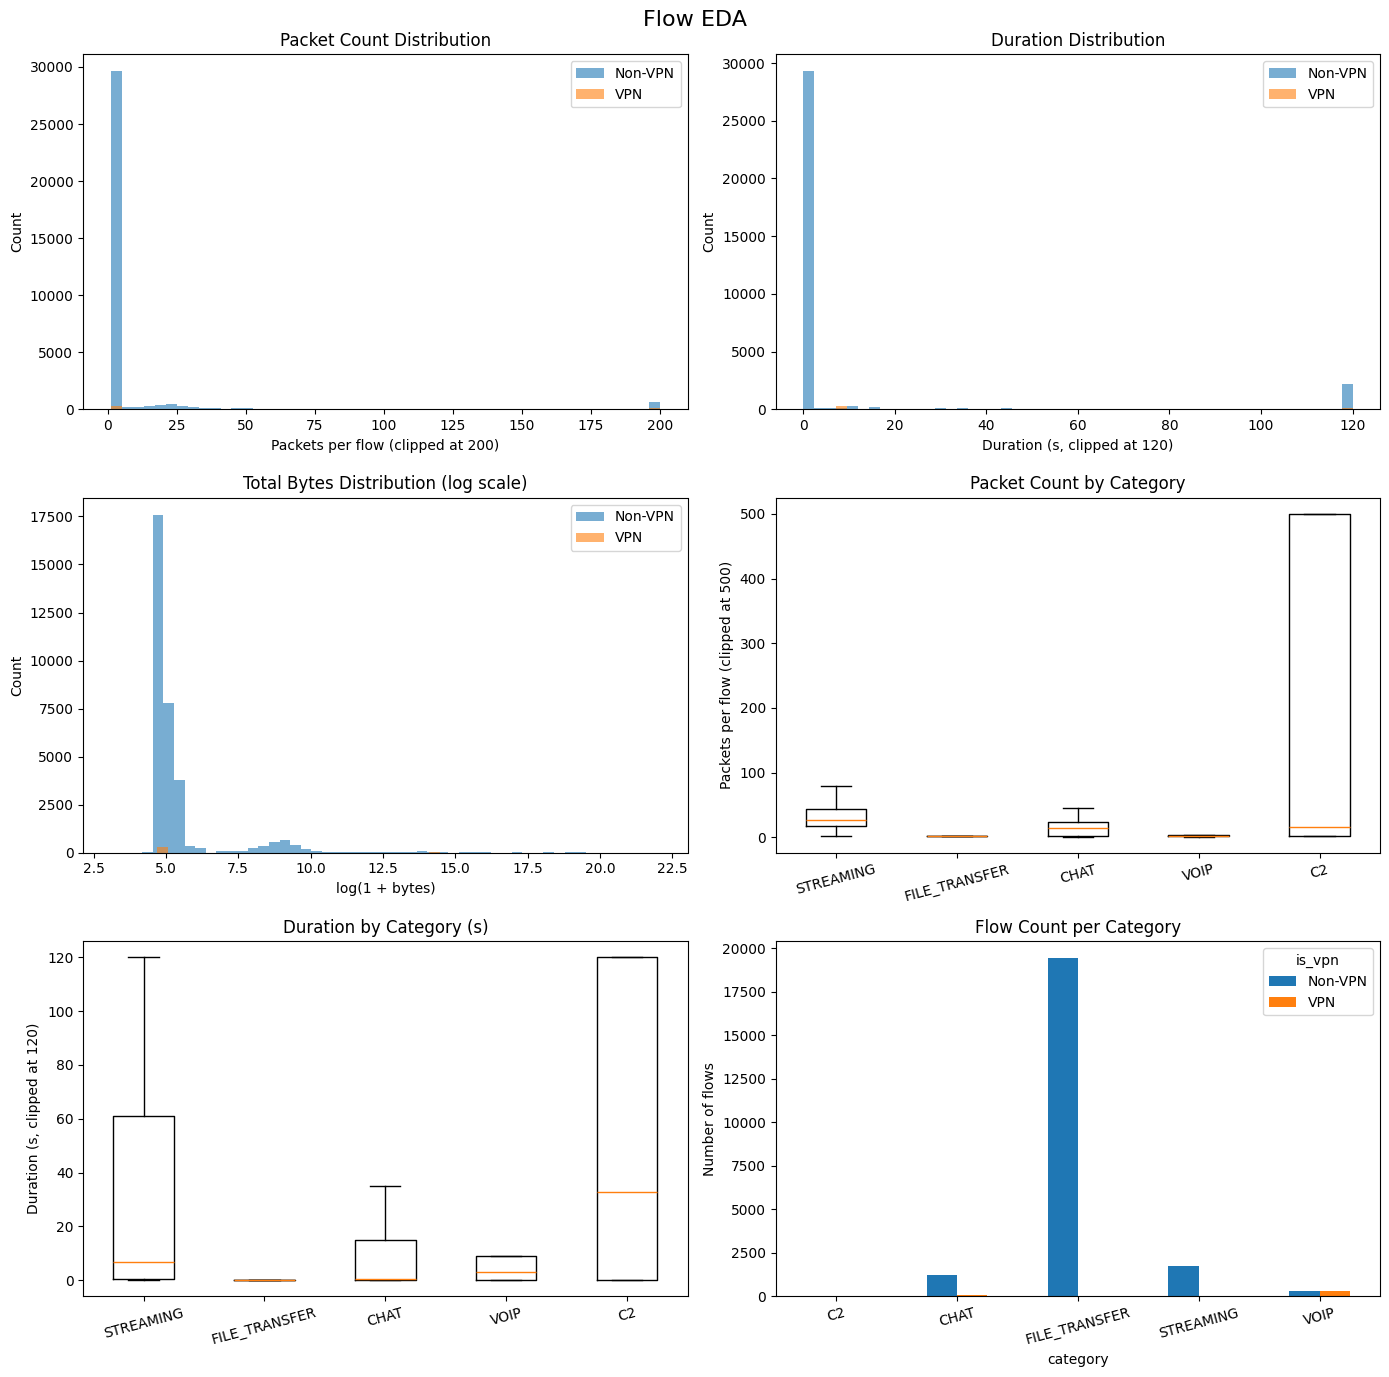

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- Compute per-flow stats ---
raw_df['packet_count'] = raw_df['sizes'].apply(len)
raw_df['duration']     = raw_df['timestamps'].apply(lambda t: t[-1] - t[0] if len(t) > 1 else 0)
raw_df['total_bytes']  = raw_df['sizes'].apply(sum)

# --- Data quality issues ---
empty_flows        = raw_df[raw_df['packet_count'] == 0]
single_pkt_flows   = raw_df[raw_df['packet_count'] == 1]
zero_duration      = raw_df[raw_df['duration'] == 0]
print(f"Empty flows:         {len(empty_flows)}")
print(f"Single-packet flows: {len(single_pkt_flows)}")
print(f"Zero-duration flows: {len(zero_duration)}")
print(f"Missing categories:  {raw_df['category'].isna().sum()}")
print(f"\nPacket count outliers (>99th pct): {(raw_df['packet_count'] > raw_df['packet_count'].quantile(0.99)).sum()}")
print(f"Duration outliers (>99th pct):     {(raw_df['duration'] > raw_df['duration'].quantile(0.99)).sum()}")

# --- Plotting ---
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Flow EDA", fontsize=16)

vpn_label = raw_df['is_vpn'].map({True: 'VPN', False: 'Non-VPN'})

# 1. Packet count distribution: VPN vs non-VPN
for label, grp in raw_df.groupby(vpn_label):
    axes[0,0].hist(np.clip(grp['packet_count'], 0, 200), bins=50, alpha=0.6, label=label)
axes[0,0].set(title='Packet Count Distribution', xlabel='Packets per flow (clipped at 200)', ylabel='Count')
axes[0,0].legend()

# 2. Duration distribution: VPN vs non-VPN
for label, grp in raw_df.groupby(vpn_label):
    axes[0,1].hist(np.clip(grp['duration'], 0, 120), bins=50, alpha=0.6, label=label)
axes[0,1].set(title='Duration Distribution', xlabel='Duration (s, clipped at 120)', ylabel='Count')
axes[0,1].legend()

# 3. Total bytes distribution: VPN vs non-VPN (log scale)
for label, grp in raw_df.groupby(vpn_label):
    axes[1,0].hist(np.log1p(grp['total_bytes']), bins=50, alpha=0.6, label=label)
axes[1,0].set(title='Total Bytes Distribution (log scale)', xlabel='log(1 + bytes)', ylabel='Count')
axes[1,0].legend()

# 4. Packet count by category (boxplot)
categories = ['STREAMING', 'FILE_TRANSFER', 'CHAT', 'VOIP', 'C2']
cat_data = [raw_df[raw_df['category'] == c]['packet_count'].clip(upper=500) for c in categories]
axes[1,1].boxplot(cat_data, labels=categories, showfliers=False)
axes[1,1].set(title='Packet Count by Category', ylabel='Packets per flow (clipped at 500)')
axes[1,1].tick_params(axis='x', rotation=15)

# 5. Duration by category (boxplot)
dur_data = [raw_df[raw_df['category'] == c]['duration'].clip(upper=120) for c in categories]
axes[2,0].boxplot(dur_data, labels=categories, showfliers=False)
axes[2,0].set(title='Duration by Category (s)', ylabel='Duration (s, clipped at 120)')
axes[2,0].tick_params(axis='x', rotation=15)

# 6. Flow count per category, split by VPN/non-VPN
counts = raw_df.groupby(['category', vpn_label]).size().unstack(fill_value=0)
counts.plot(kind='bar', ax=axes[2,1], rot=15)
axes[2,1].set(title='Flow Count per Category', ylabel='Number of flows')

plt.tight_layout()
plt.show()


In [11]:
raw_df['is_vpn'].value_counts()

is_vpn
False    33332
True       379
Name: count, dtype: int64